# 05 · Preference latent space (Exp3) — *Mass-Mean-Probe* (PTO only)

**PTO-only by construction.** GRPO has no chosen/rejected pairs (see CLAUDE.md "Vocabulary"), so this
notebook iterates only PTO arms. Over each PTO arm's `pref_pairs/pairs.csv`: probe quality, the
chosen-vs-rejected word ranking, and MI-concept projection across iterations (the `pref_emb` successor).

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()      # S.ARMS, S.SCORES, S.PALETTE, S.METRICS, S.ORACLE_NOISE, S.RESULTS_DIR

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 0 · PTO arms with preference data

In [2]:
PTO_ARMS = [a for a in S.ARMS if a.method == "PTO" and len(training.load_pref_pairs([a]))]
print("PTO arms with pref pairs:", [a.label for a in PTO_ARMS])

PTO arms with pref pairs: ['PTO_LA0', 'PTO_LA5']


## 1 · Per-arm latent-space preference (probe quality → word ranking → MI concepts)
One pipeline, run for each PTO arm. Embeddings are cached to `exp3/.emb_cache/`.


################  PTO_LA0  ################
probe quality per iter (wins_correct should be > 0.5):


,train_iter,n,wins_correct,mean_gap,mean_margin
0,1,782,0.6509,0.0517,0.3217
1,2,618,0.6553,0.0629,0.2988
2,3,620,0.6097,0.0493,0.2946
3,4,536,0.6511,0.0510,0.2690
4,5,483,0.6605,0.0493,0.2812
5,6,475,0.6926,0.0605,0.2673
6,7,400,0.6825,0.0513,0.2718
7,8,379,0.6623,0.0629,0.2491
8,9,361,0.7175,0.0594,0.2657
9,10,281,0.7082,0.0624,0.2667


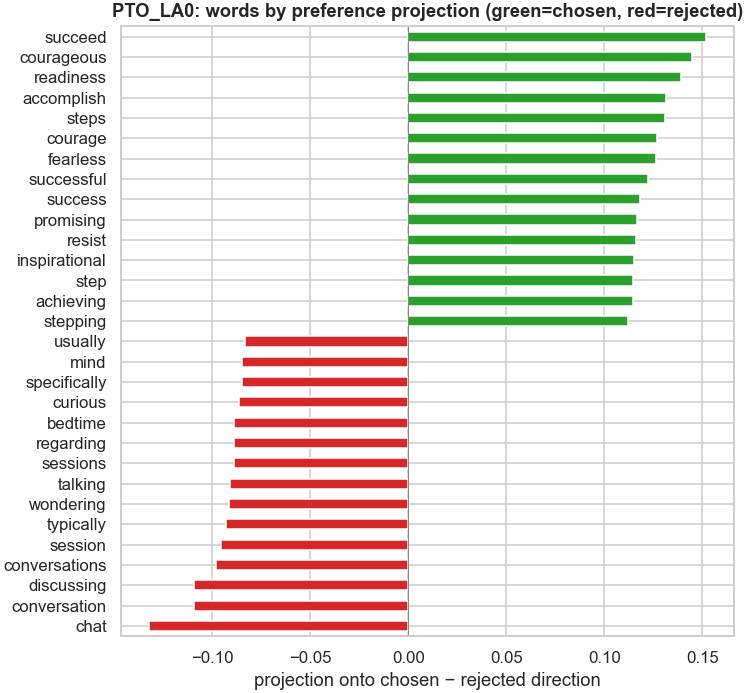

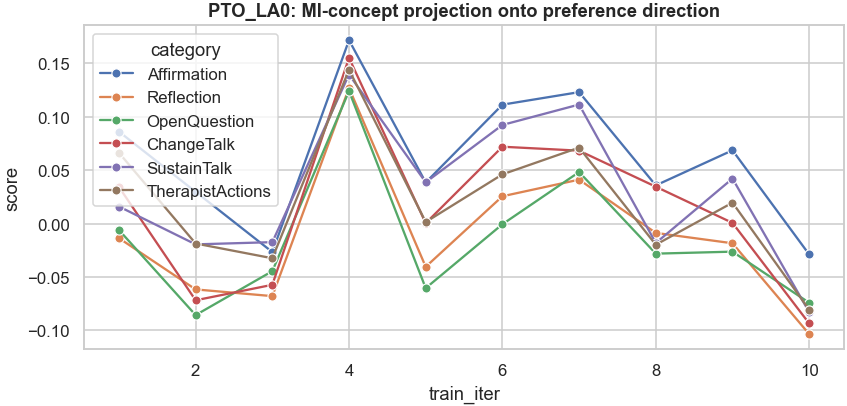

[INFO] Running in WANDB offline mode


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


################  PTO_LA5  ################
probe quality per iter (wins_correct should be > 0.5):


,train_iter,n,wins_correct,mean_gap,mean_margin
0,1,832,0.6430,0.0817,0.4512
1,2,778,0.6093,0.0725,0.4614
2,3,768,0.6615,0.0748,0.4705
3,4,563,0.6199,0.0566,0.4260
4,5,432,0.6551,0.0561,0.4086


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

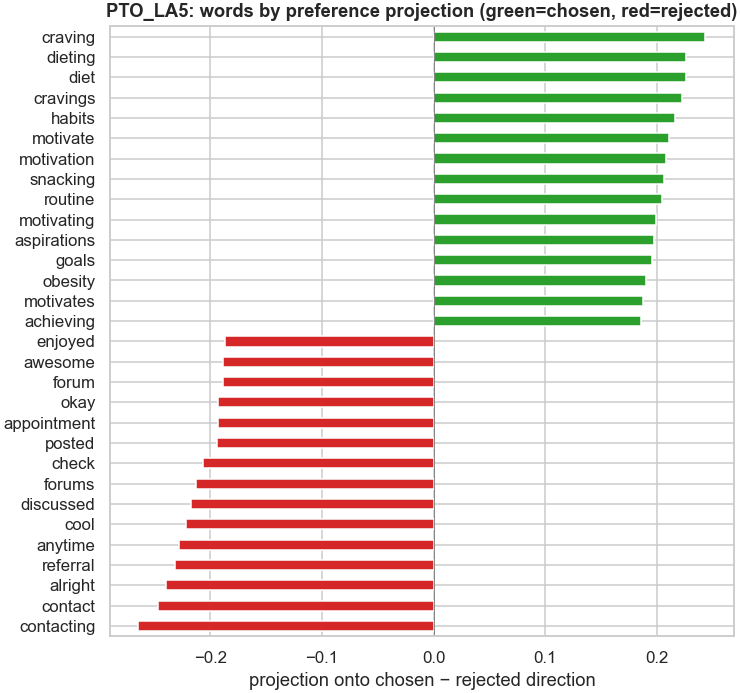

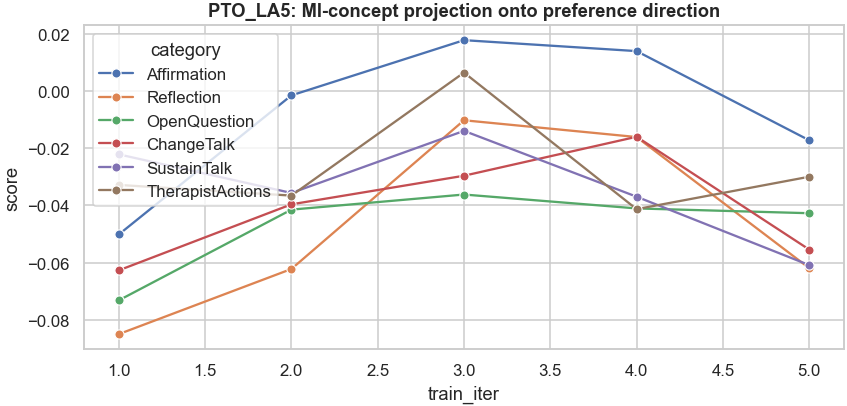

In [3]:
def analyze_pref(arm):
    PAIRS = pref.add_text_features(training.load_pref_pairs([arm]))
    if PAIRS.empty:
        print(f"{arm.label}: no pairs."); return
    EMB = pref.embed_pairs(PAIRS)
    DIRS = pref.preference_direction_by_iter(EMB)
    PQ = pref.probe_quality_by_iter(EMB, DIRS)
    print(f"\n################  {arm.label}  ################")
    print("probe quality per iter (wins_correct should be > 0.5):"); display(PQ.round(4))
    exp3.save_table(PQ.round(4), f"{arm.label}_pref_probe_quality", caption=f"{arm.label} preference-probe quality per iteration (wins_correct, gap, margin).")
    words, wmat = pref.embed_vocab(pref.build_vocab(PAIRS, top_n=3000)); WP = pref.word_projection(words, wmat, DIRS)
    fig = pref.pref_word_ranking(WP, title=f"{arm.label}: words by preference projection (green=chosen, red=rejected)")
    if fig: exp3.save_fig(fig, f"{arm.label}_pref_word_ranking", caption=f"{arm.label} top chosen/rejected-aligned words (Mass Mean Probe, pooled over iters)."); plt.show()
    CAT = pref.category_projection(DIRS)
    if not CAT.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.lineplot(CAT, x="train_iter", y="score", hue="category", marker="o", ax=ax)
        ax.set_title(f"{arm.label}: MI-concept projection onto preference direction"); fig.tight_layout(); plt.show()
        exp3.save_table(CAT.round(4), f"{arm.label}_pref_MI_concepts", caption=f"{arm.label} MI-concept projection onto the preference direction per iteration.")

for arm in PTO_ARMS:
    analyze_pref(arm)
if not PTO_ARMS:
    print("No PTO arm with preference pairs scored yet.")

## 2 · Takeaways
- `wins_correct` well above 0.5 means the Mass-Mean-Probe direction genuinely separates chosen from
  rejected — a real, readable preference axis.
- The **word ranking** + **MI-concept projection** read out *what* the policy increasingly prefers; rising
  `Affirmation` over iterations is the latent-space signature of the affirmation drift seen in `04`.
- GRPO has no analog here by design (no pairs); its training signal lives in `02` (group_std).